# Logistic Regression — Aimon V1

**Data:** `data/aimon-data/` — V1 pipeline (94 features, StandardScaler already applied)  
**Split:** 70 / 15 / 15 (4,773 train / 1,023 val / 1,023 test)  
**Class balance:** 3.23% bankrupt — handled via `class_weight='balanced'`  
**Primary metrics:** Recall and PR-AUC (false negatives are costly)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)

DATA_DIR = Path('../data/aimon-data')
RANDOM_STATE = 42

## 1. Load Data

In [2]:
X_train = pd.read_csv(DATA_DIR / 'X_train_v1.csv')
X_val   = pd.read_csv(DATA_DIR / 'X_val_v1.csv')
X_test  = pd.read_csv(DATA_DIR / 'X_test_v1.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(DATA_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | bankrupt={y_train.mean()*100:.2f}%')
print(f'Val:   {X_val.shape}   | bankrupt={y_val.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}  | bankrupt={y_test.mean()*100:.2f}%')

Train: (4773, 94) | bankrupt=3.23%
Val:   (1023, 94)   | bankrupt=3.23%
Test:  (1023, 94)  | bankrupt=3.23%


## 2. Train Logistic Regression

Data is already StandardScaled. Use `class_weight='balanced'` to handle the 3.23% imbalance.

In [3]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


## 3. Threshold Tuning on Validation Set

Default threshold (0.5) often misses bankruptcies. Find the threshold that maximises F1 on val.

Best threshold (max F1 on val): 0.8255
  Val F1=0.4667 | Recall=0.6364 | Precision=0.3684


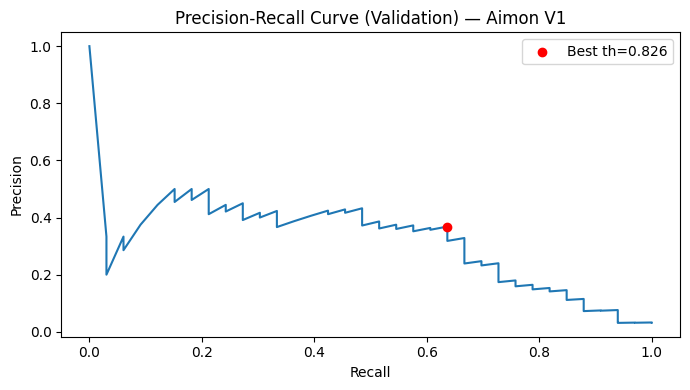

In [4]:
y_val_prob = model.predict_proba(X_val)[:, 1]

precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, y_val_prob)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-8)
best_idx = np.argmax(f1_arr)
best_th  = thresholds[best_idx]

print(f'Best threshold (max F1 on val): {best_th:.4f}')
print(f'  Val F1={f1_arr[best_idx]:.4f} | Recall={recall_arr[best_idx]:.4f} | Precision={precision_arr[best_idx]:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(recall_arr, precision_arr)
plt.scatter(recall_arr[best_idx], precision_arr[best_idx], color='red', zorder=5, label=f'Best th={best_th:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation) — Aimon V1')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Evaluate on Test Set

In [5]:
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_th).astype(int)

auc    = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)
f1     = f1_score(y_test, y_test_pred)
rec    = recall_score(y_test, y_test_pred)
prec   = precision_score(y_test, y_test_pred)

print('=== Test Results — Logistic Regression (Aimon V1) ===')
print(f'AUC:       {auc:.4f}')
print(f'PR-AUC:    {pr_auc:.4f}  ← primary metric')
print(f'Recall:    {rec:.4f}  ← primary metric')
print(f'F1:        {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Threshold: {best_th:.4f}')
print()
print('Confusion Matrix (rows=actual, cols=predicted):')
print(confusion_matrix(y_test, y_test_pred))
print()
print(classification_report(y_test, y_test_pred, target_names=['Solvent', 'Bankrupt']))

=== Test Results — Logistic Regression (Aimon V1) ===
AUC:       0.8728
PR-AUC:    0.2491  ← primary metric
Recall:    0.5455  ← primary metric
F1:        0.3564
Precision: 0.2647
Threshold: 0.8255

Confusion Matrix (rows=actual, cols=predicted):
[[940  50]
 [ 15  18]]

              precision    recall  f1-score   support

     Solvent       0.98      0.95      0.97       990
    Bankrupt       0.26      0.55      0.36        33

    accuracy                           0.94      1023
   macro avg       0.62      0.75      0.66      1023
weighted avg       0.96      0.94      0.95      1023



## 5. Top Coefficients (Feature Importance)

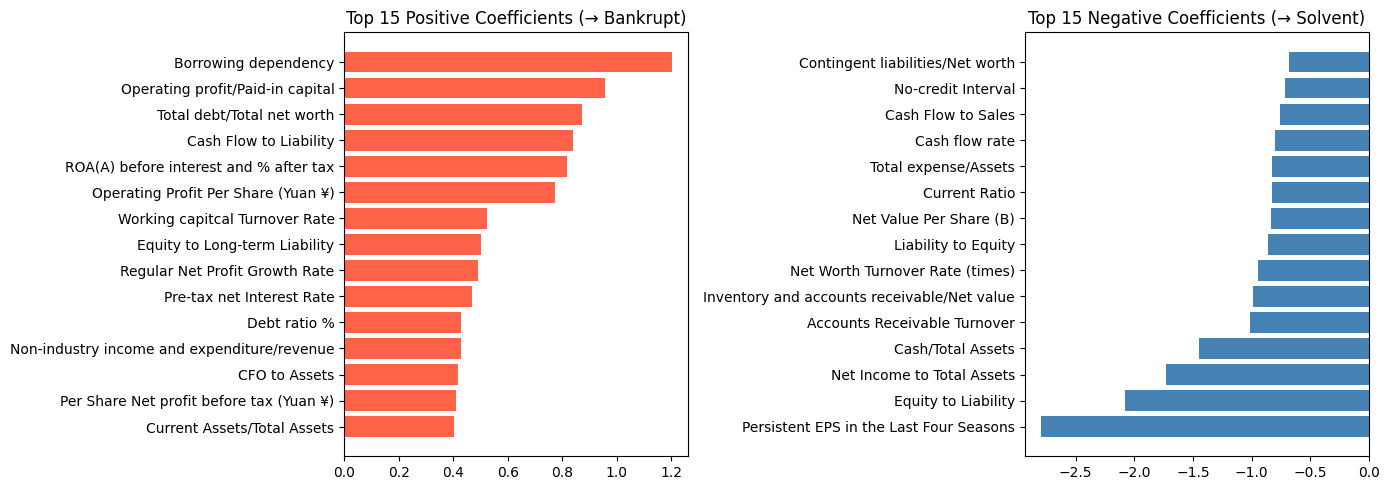

In [6]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
}).reindex(model.coef_[0].argsort()[::-1])

top_n = 15
top_pos = coef_df.head(top_n)
top_neg = coef_df.tail(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_pos['feature'], top_pos['coefficient'], color='tomato')
axes[0].set_title(f'Top {top_n} Positive Coefficients (→ Bankrupt)')
axes[0].invert_yaxis()
axes[1].barh(top_neg['feature'], top_neg['coefficient'], color='steelblue')
axes[1].set_title(f'Top {top_n} Negative Coefficients (→ Solvent)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()